# Decision Tree

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['figure.dpi']=250
import warnings
warnings.filterwarnings('ignore')

# Data Preparation

In [2]:
df = pd.read_csv("heart_disease.csv")

In [3]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,FALSE,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,FALSE,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,FALSE,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,FALSE,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,TRUE,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,FALSE,1.5,upsloping,fixed defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,TRUE,3.0,flat,normal,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,TRUE,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


# Exploratory Data Analysis (EDA):

In [4]:
df.shape

(908, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

In [7]:
df['exang'].value_counts()

exang
FALSE    535
TRUE     337
TURE      36
Name: count, dtype: int64

In [8]:
df['exang'].replace({'TURE':True,'TRUE':True,'FALSE':False},inplace=True)

In [9]:
df['exang'].value_counts()

exang
False    535
True     373
Name: count, dtype: int64

In [10]:
df['exang']=df['exang'].astype(bool)

In [11]:
df.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang          bool
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

In [12]:
df.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

<AxesSubplot:>

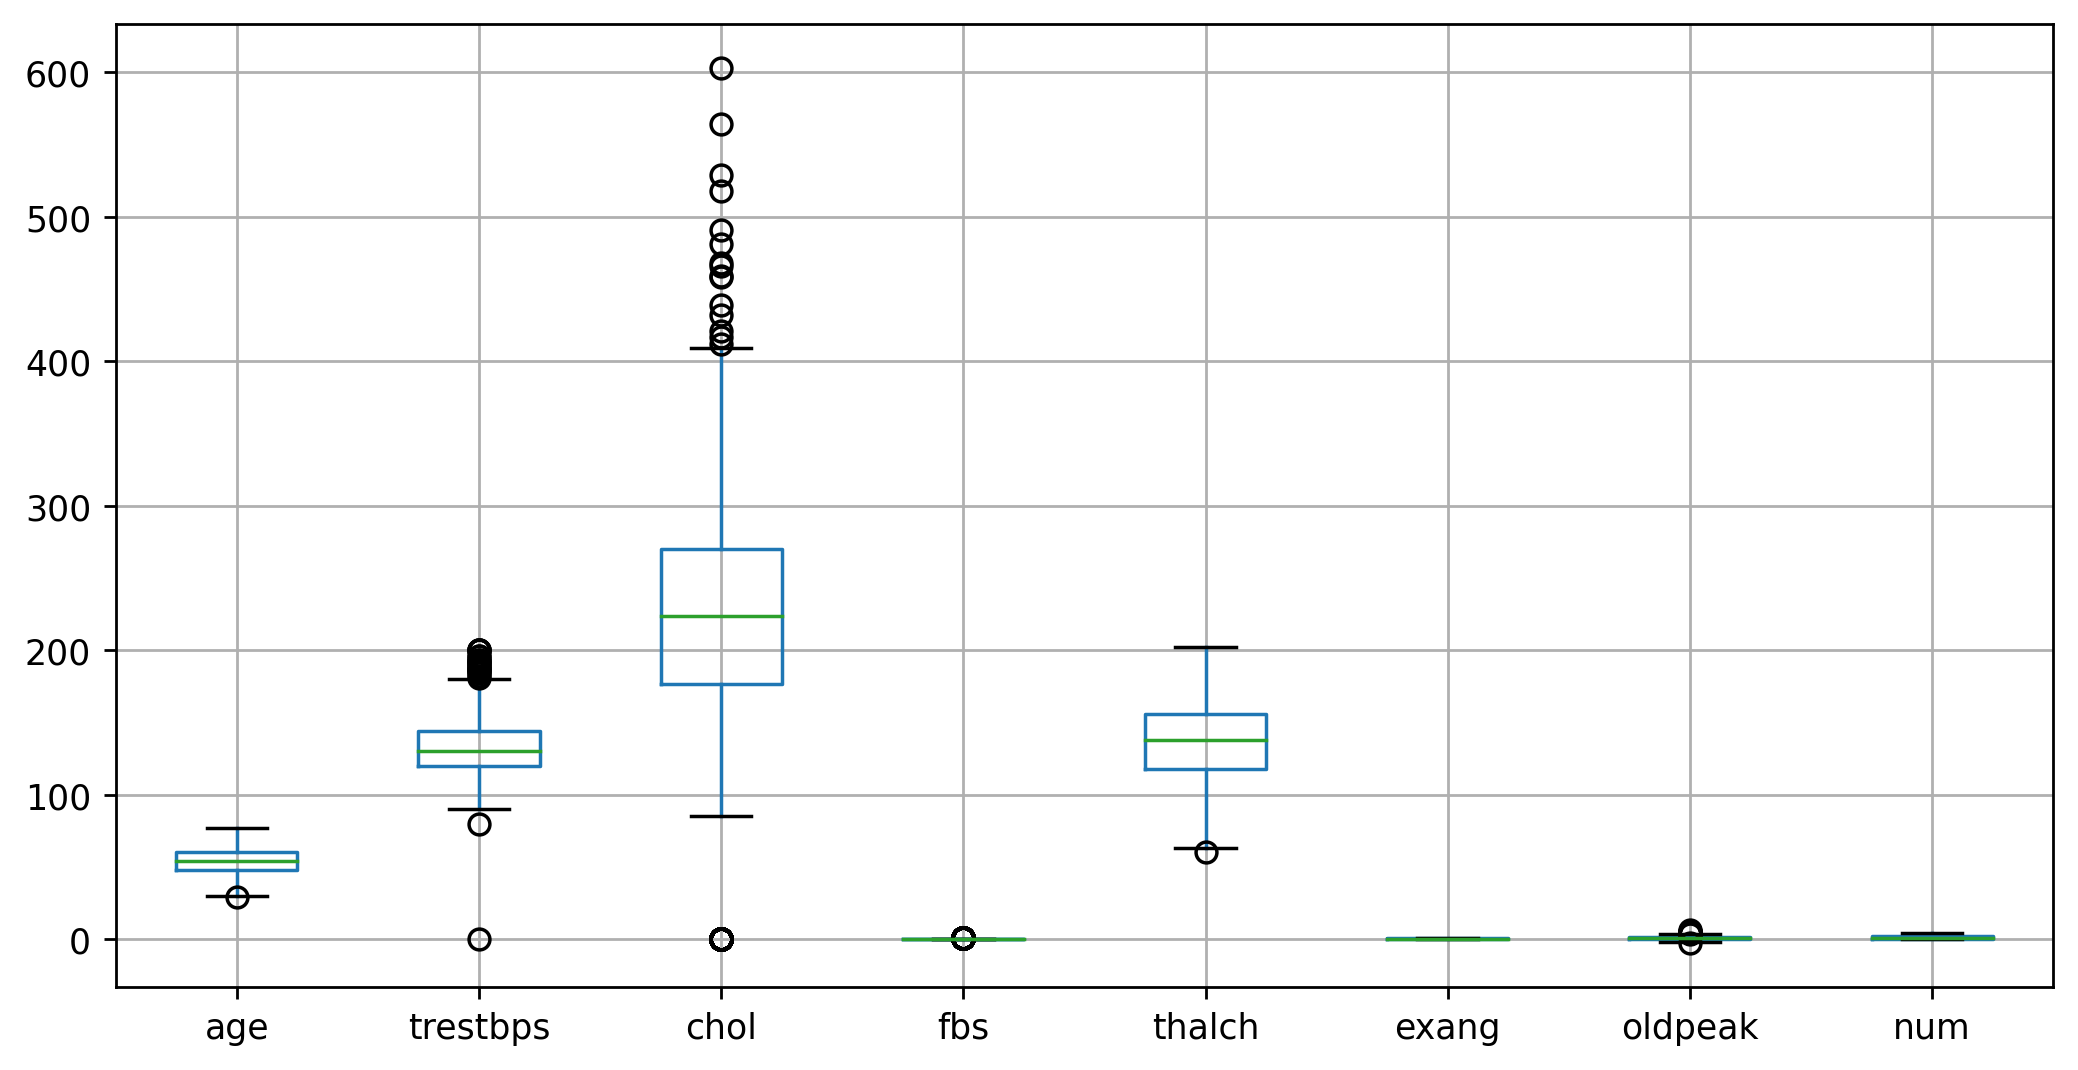

In [13]:
df.boxplot()

In [14]:
df['oldpeak'].fillna(df['oldpeak'].median(),inplace=True)

In [15]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [16]:
df.duplicated().sum()

1

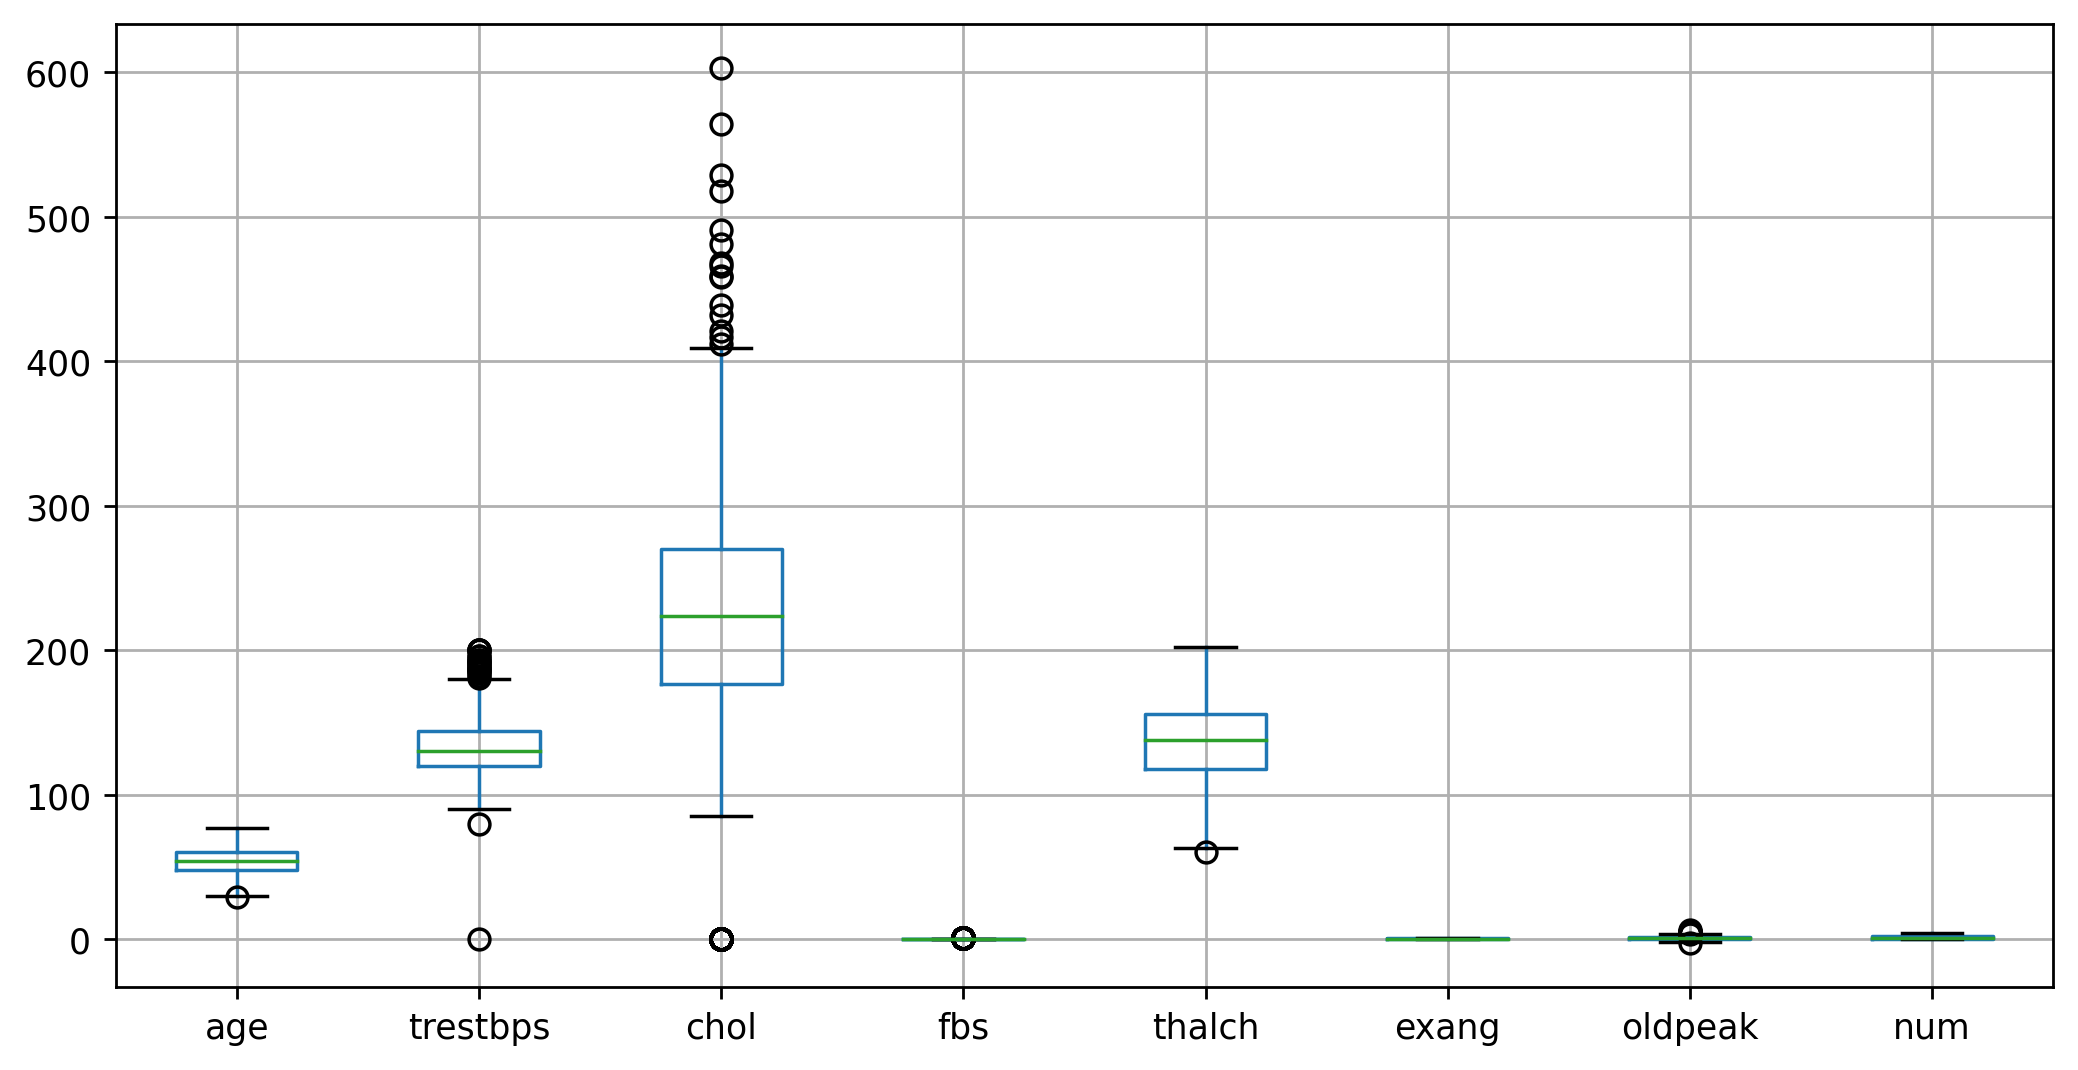

In [17]:
df.boxplot()
plt.show()

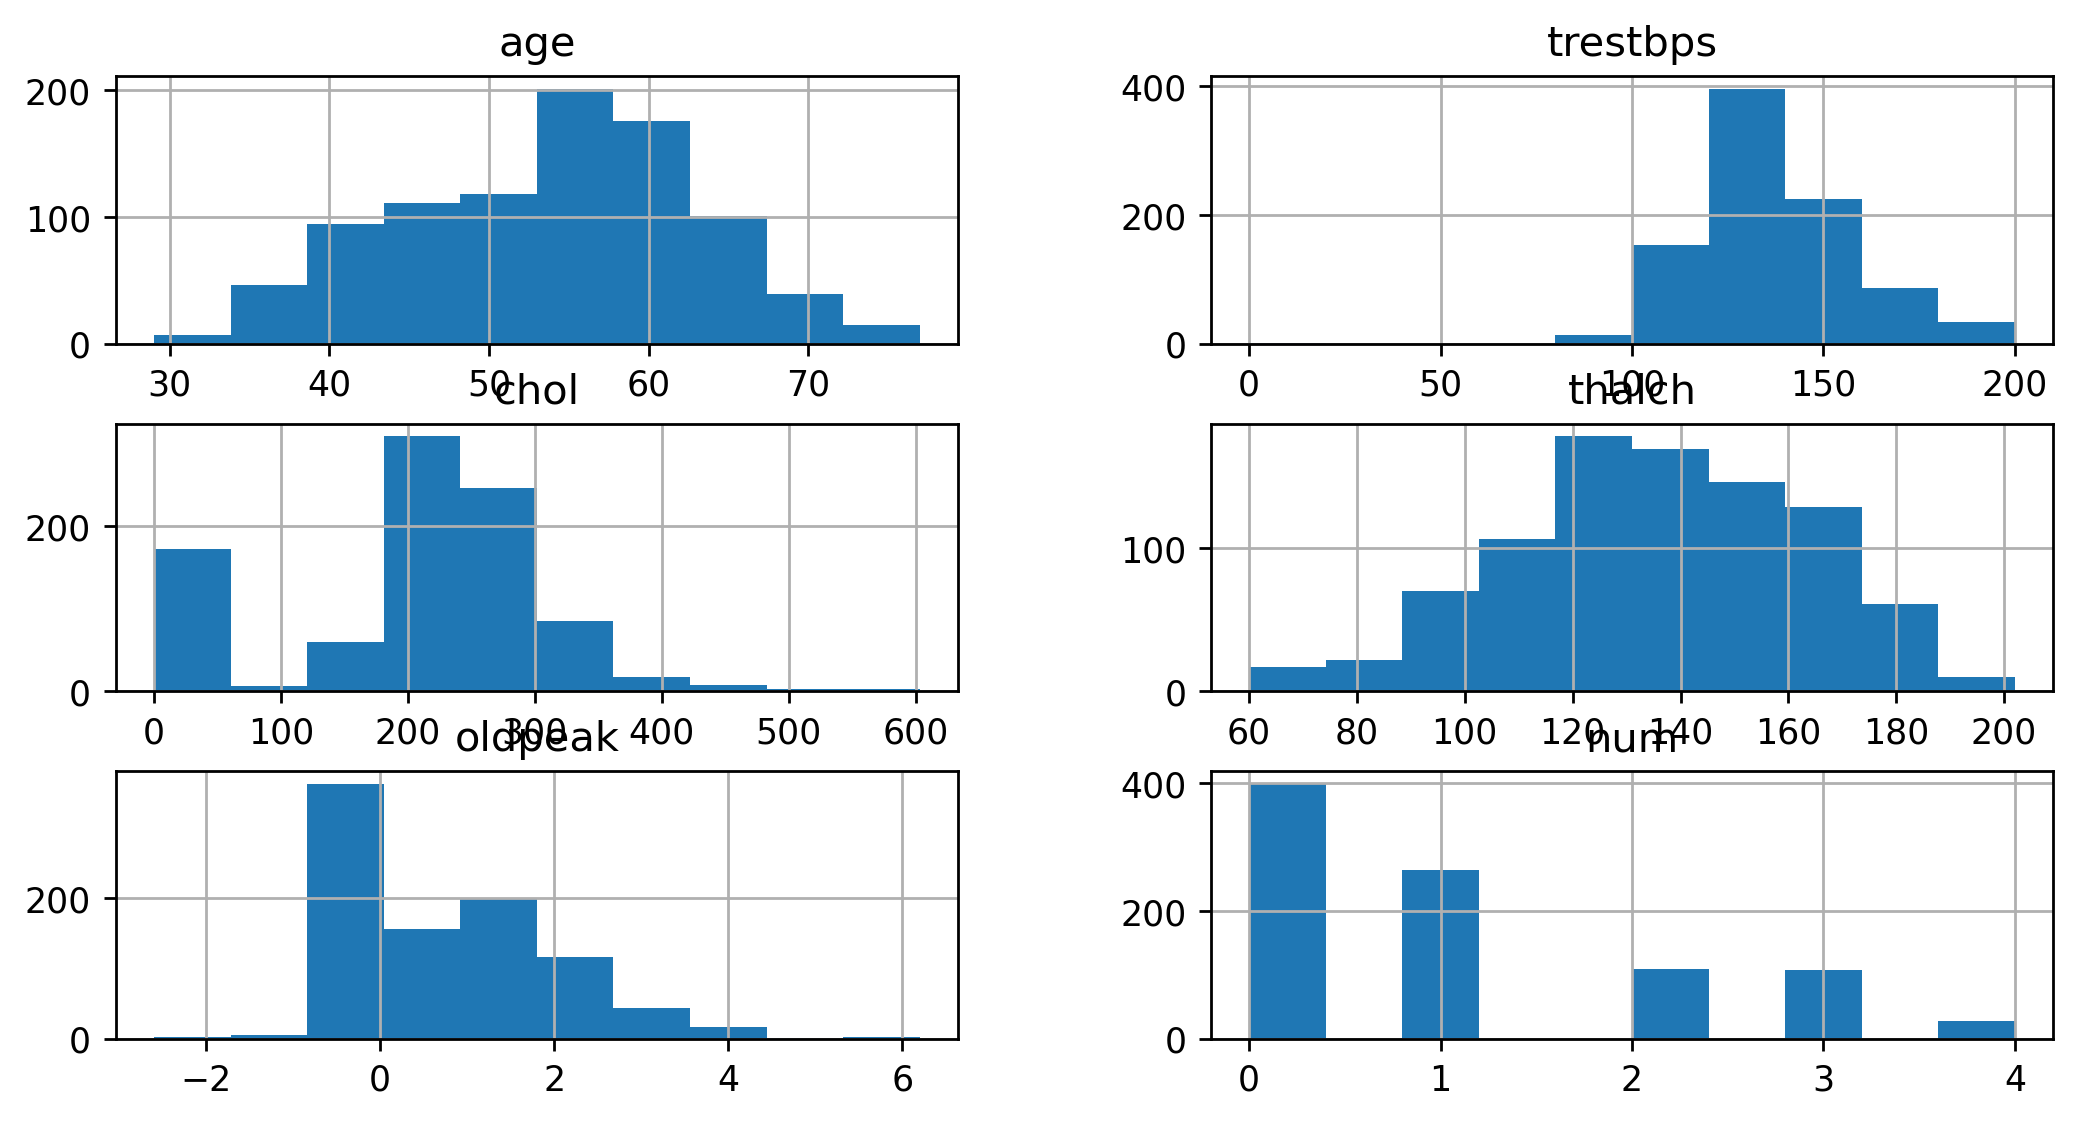

<function matplotlib.pyplot.tight_layout(*, pad=1.08, h_pad=None, w_pad=None, rect=None)>

In [18]:
df.hist()
plt.show()
plt.tight_layout

In [19]:
df['num'].value_counts()

num
0    399
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [20]:
df.corr(numeric_only=True)

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num
age,1.000000,0.253999,-0.099967,0.176702,-0.328088,0.192634,0.217942,0.326493
trestbps,0.253999,1.000000,0.117488,0.111614,-0.133360,0.151984,0.134945,0.137251
chol,-0.099967,0.117488,1.000000,-0.113721,0.197907,-0.037019,0.032205,-0.238813
fbs,0.176702,0.111614,-0.113721,1.000000,-0.065428,0.027807,0.008154,0.156268
thalch,-0.328088,-0.133360,0.197907,-0.065428,1.000000,-0.349191,-0.112624,-0.323058
exang,0.192634,0.151984,-0.037019,0.027807,-0.349191,1.000000,0.355955,0.359549
oldpeak,0.217942,0.134945,0.032205,0.008154,-0.112624,0.355955,1.000000,0.406078
num,0.326493,0.137251,-0.238813,0.156268,-0.323058,0.359549,0.406078,1.000000


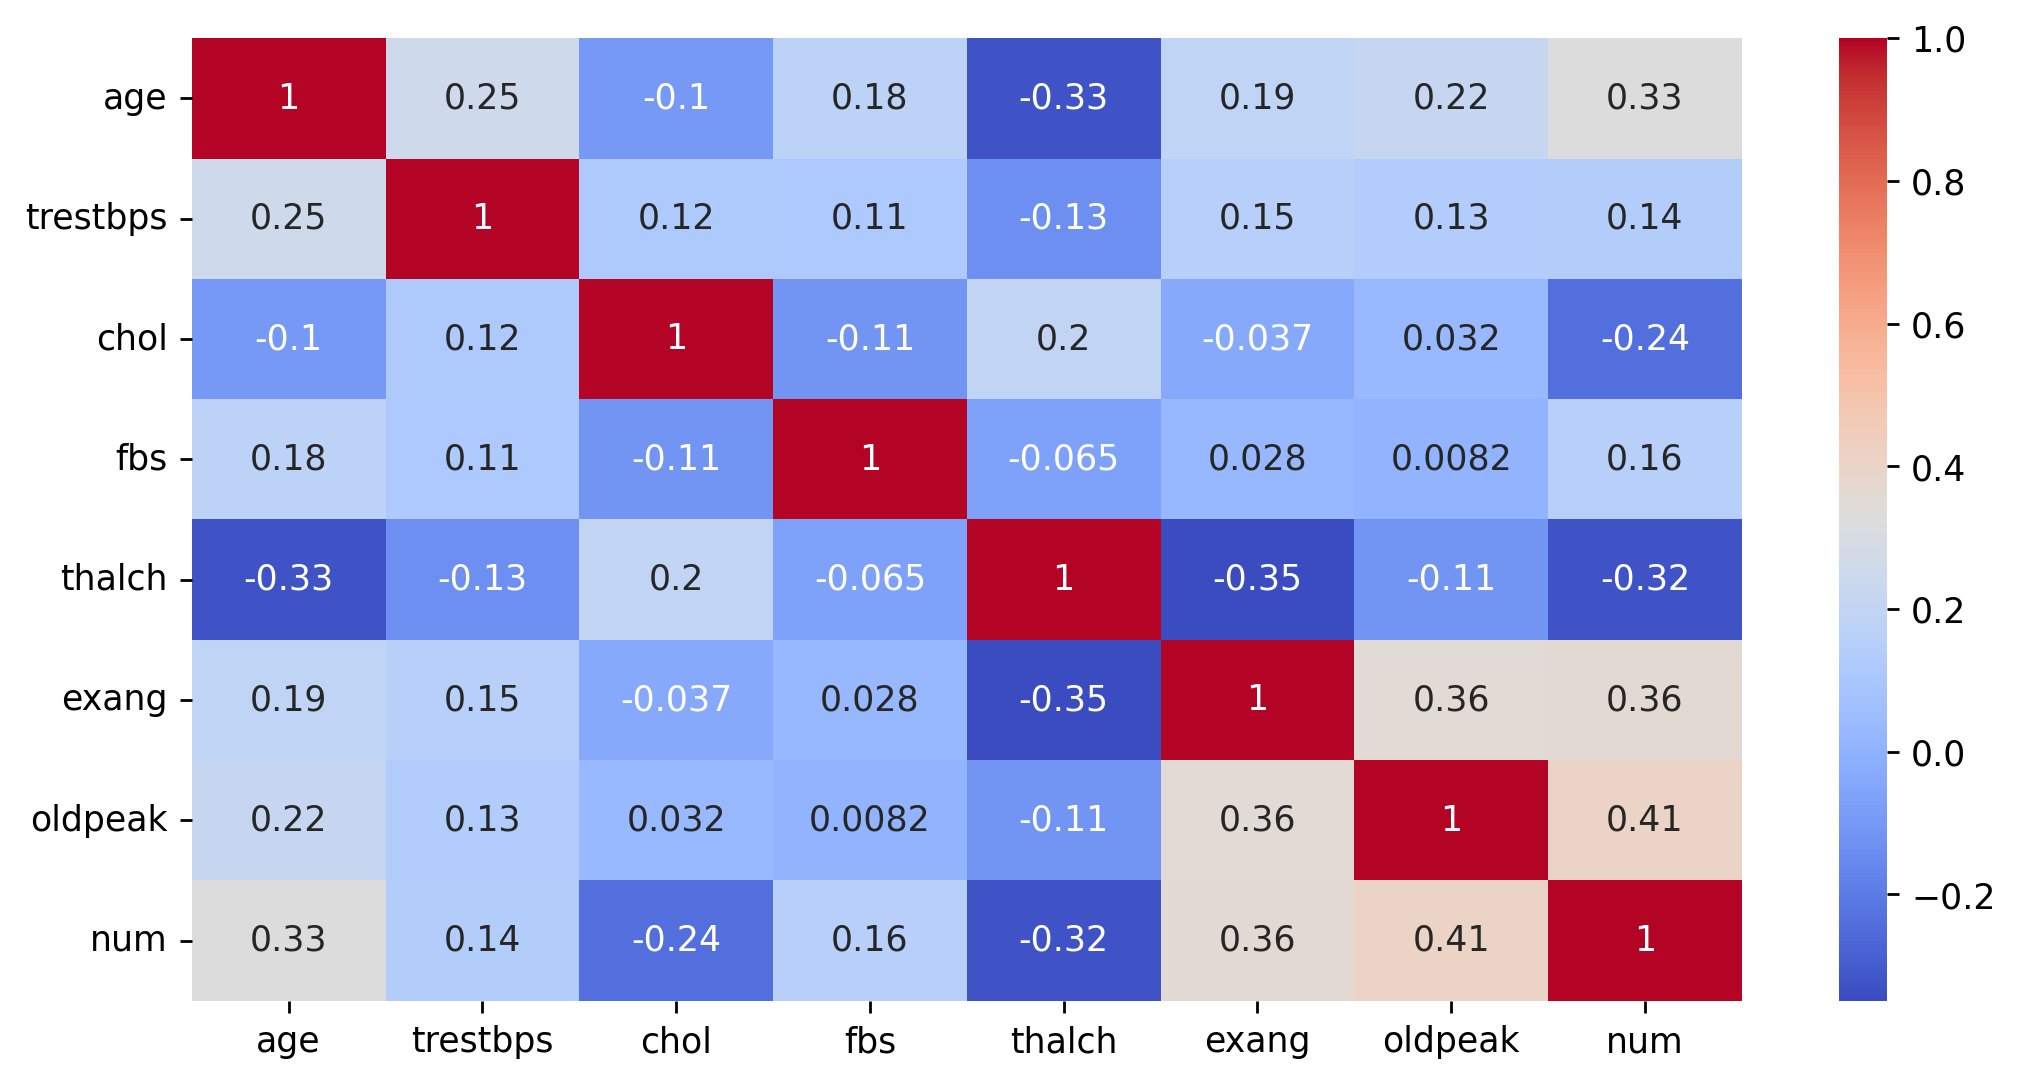

In [21]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

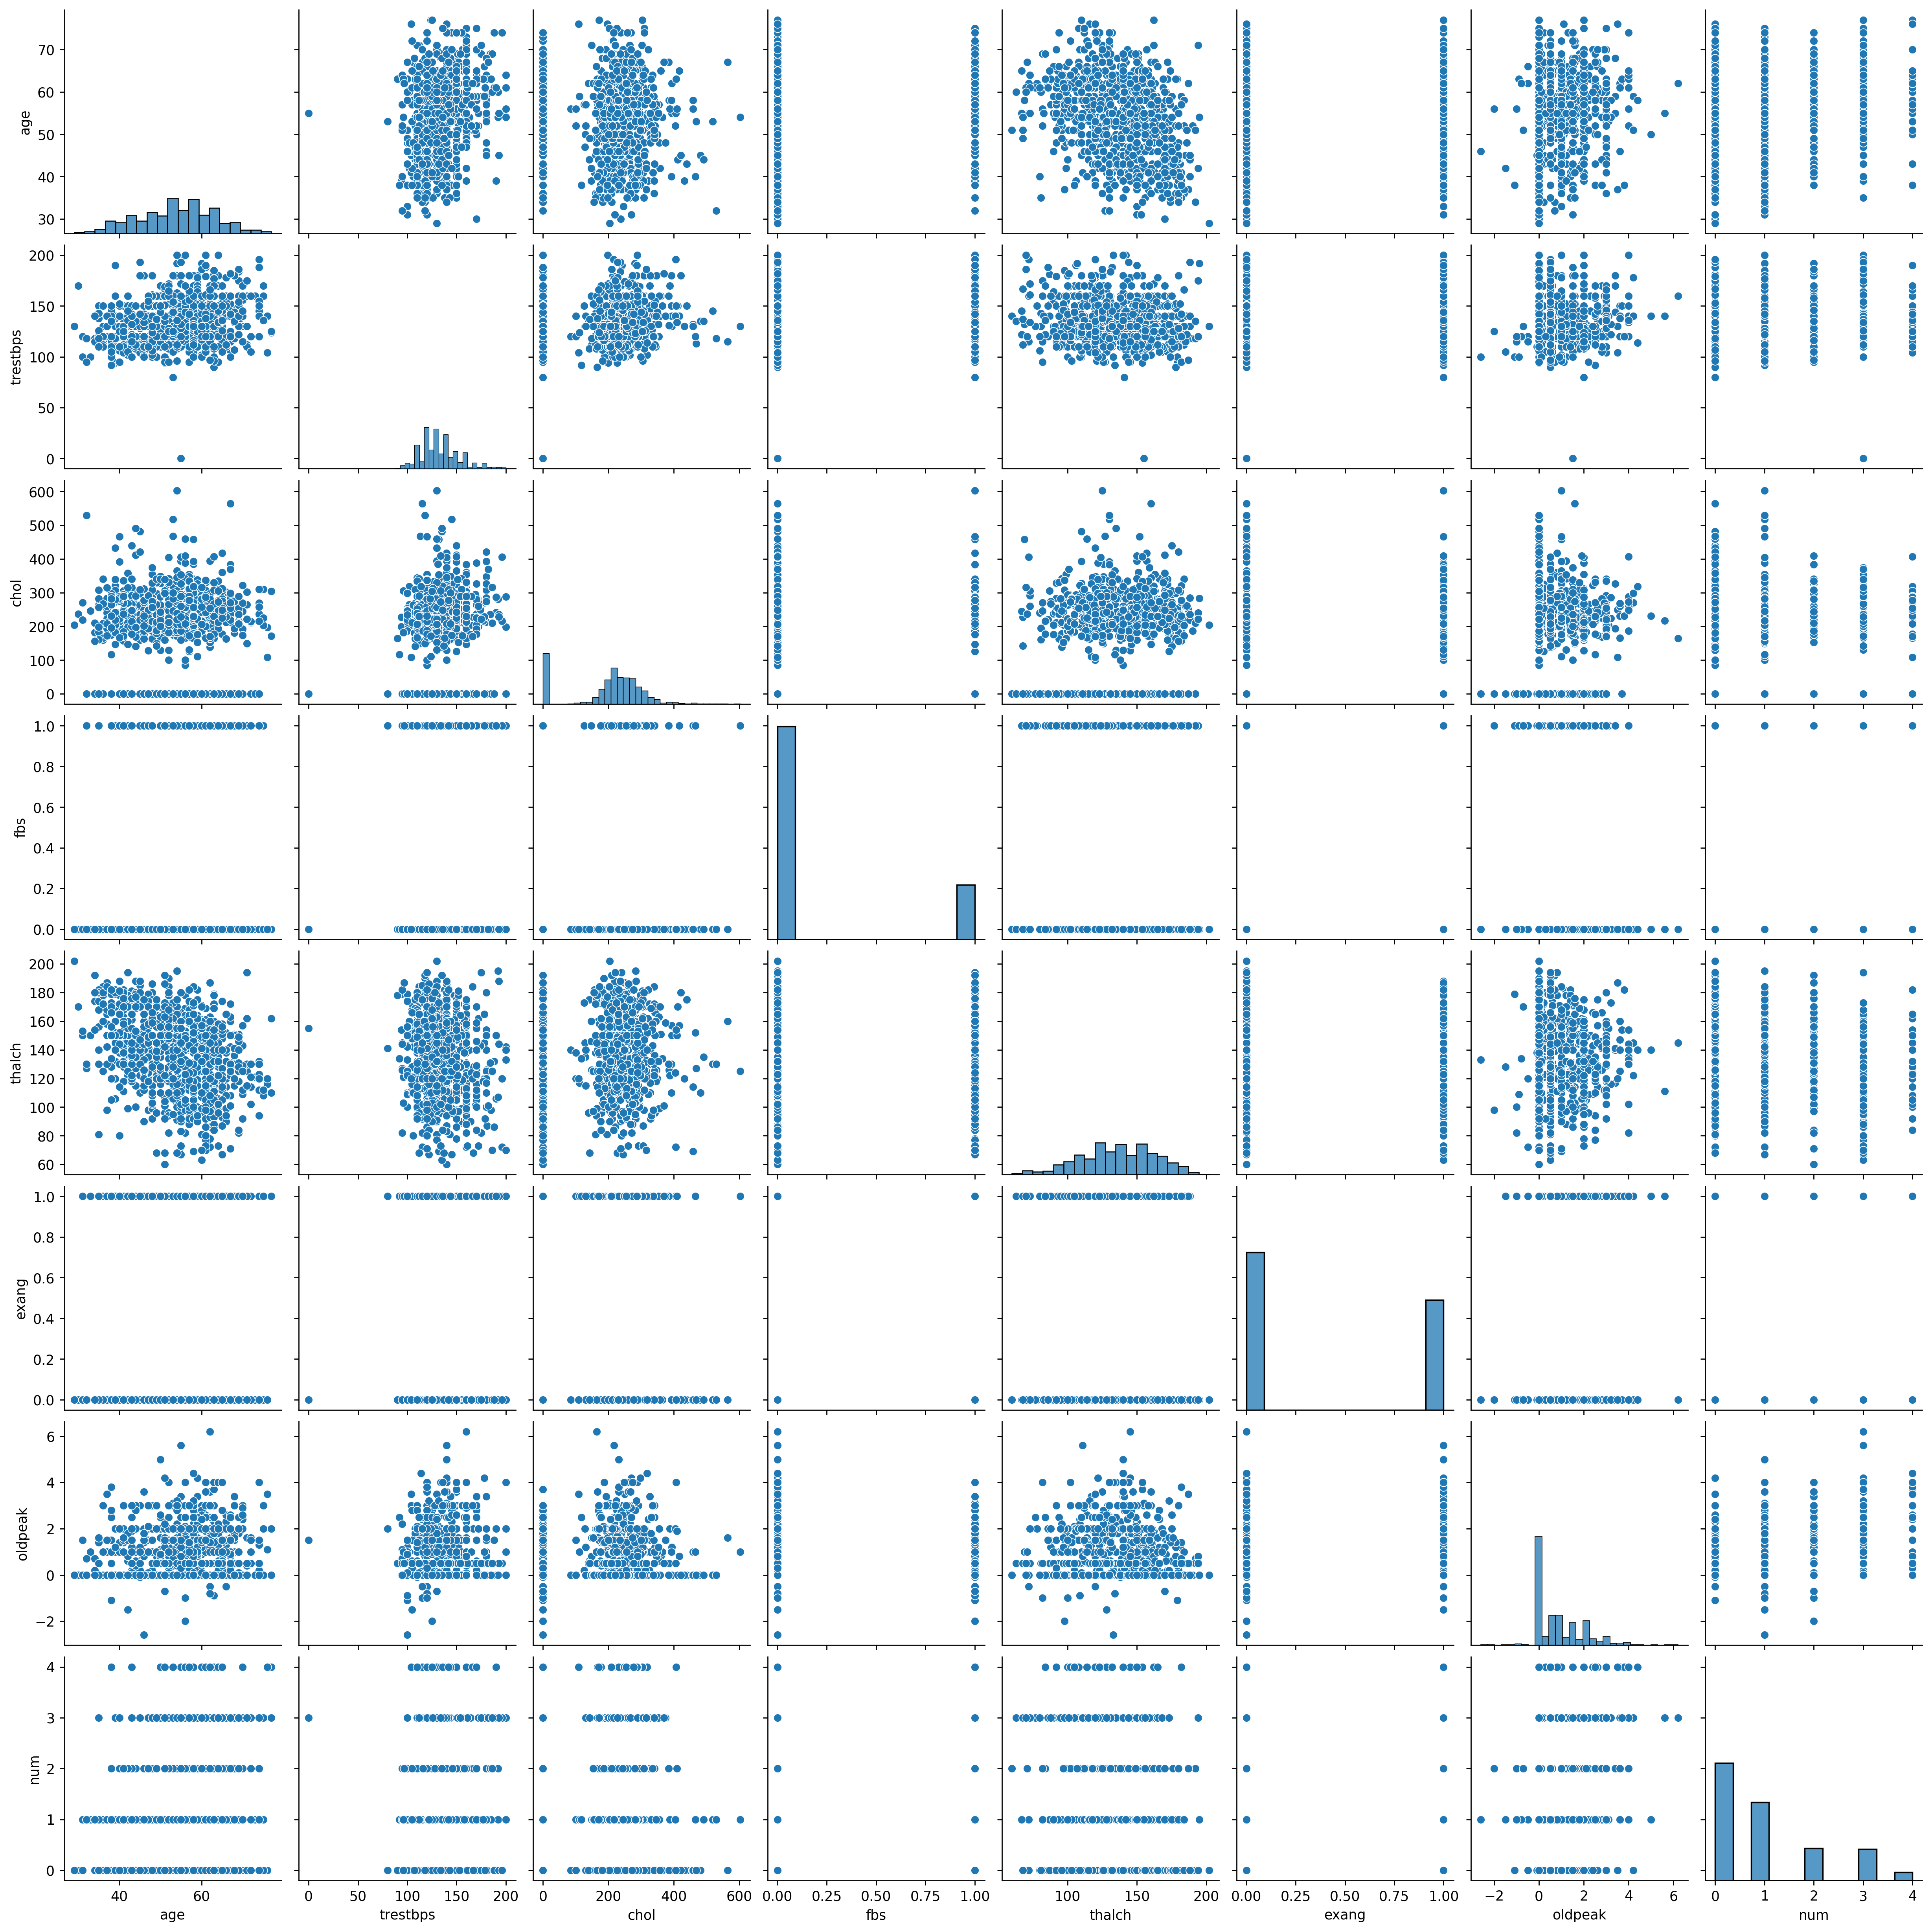

In [22]:
sns.pairplot(df)
plt.show()

# Feature Engineering:

In [23]:
df.head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0


In [24]:
obj=['sex','cp','restecg','slope','thal']


In [25]:
df[obj]

,sex,cp,restecg,slope,thal
0,Male,typical angina,lv hypertrophy,downsloping,fixed defect
1,Male,atypical angina,normal,flat,fixed defect
2,Male,asymptomatic,normal,flat,fixed defect
3,Male,typical angina,lv hypertrophy,flat,fixed defect
4,Male,asymptomatic,normal,flat,fixed defect
...,...,...,...,...,...
903,Male,asymptomatic,normal,upsloping,fixed defect
904,Male,asymptomatic,st-t abnormality,flat,normal
905,Male,non-anginal,lv hypertrophy,downsloping,normal
906,Male,non-anginal,st-t abnormality,downsloping,reversable defect


In [26]:
oe=OrdinalEncoder()
df[obj]=oe.fit_transform(df[obj])

In [27]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1.0,3.0,145,233,True,0.0,150,False,2.3,0.0,0.0,0
1,41,1.0,1.0,135,203,False,1.0,132,False,0.0,1.0,0.0,0
2,57,1.0,0.0,140,192,False,1.0,148,False,0.4,1.0,0.0,0
3,52,1.0,3.0,118,186,False,0.0,190,False,0.0,1.0,0.0,0
4,57,1.0,0.0,110,201,False,1.0,126,True,1.5,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,1.0,0.0,125,0,False,1.0,120,False,1.5,2.0,0.0,4
904,62,1.0,0.0,166,170,False,2.0,120,True,3.0,1.0,1.0,4
905,56,1.0,2.0,170,0,False,0.0,123,True,2.5,0.0,1.0,4
906,56,1.0,2.0,144,208,True,2.0,105,True,0.5,0.0,2.0,4


In [28]:
x=df.iloc[:,0:-1]
y=df['num']

In [29]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
0,63,1.0,3.0,145,233,True,0.0,150,False,2.3,0.0,0.0
1,41,1.0,1.0,135,203,False,1.0,132,False,0.0,1.0,0.0
2,57,1.0,0.0,140,192,False,1.0,148,False,0.4,1.0,0.0
3,52,1.0,3.0,118,186,False,0.0,190,False,0.0,1.0,0.0
4,57,1.0,0.0,110,201,False,1.0,126,True,1.5,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,1.0,0.0,125,0,False,1.0,120,False,1.5,2.0,0.0
904,62,1.0,0.0,166,170,False,2.0,120,True,3.0,1.0,1.0
905,56,1.0,2.0,170,0,False,0.0,123,True,2.5,0.0,1.0
906,56,1.0,2.0,144,208,True,2.0,105,True,0.5,0.0,2.0


In [30]:
y

0      0
1      0
2      0
3      0
4      0
      ..
903    4
904    4
905    4
906    4
907    4
Name: num, Length: 908, dtype: int64

In [31]:
sc=StandardScaler()
x=pd.DataFrame(sc.fit_transform(x),columns=x.columns)
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
0,1.006027,0.514416,2.320276,0.567394,0.281297,1.976894,-1.561352,0.524183,-0.834983,1.354403,-1.672770,-1.508740
1,-1.397560,0.514416,0.232258,0.076967,0.013526,-0.505844,0.013879,-0.147705,-0.834983,-0.815718,-0.224843,-1.508740
2,0.350503,0.514416,-0.811752,0.322181,-0.084656,-0.505844,0.013879,0.449529,-0.834983,-0.438305,-0.224843,-1.508740
3,-0.195767,0.514416,2.320276,-0.756760,-0.138211,-0.505844,-1.561352,2.017268,-0.834983,-0.815718,-0.224843,-1.508740
4,0.350503,0.514416,-0.811752,-1.149102,-0.004325,-0.505844,0.013879,-0.371668,1.197629,0.599578,-0.224843,-1.508740
...,...,...,...,...,...,...,...,...,...,...,...,...
903,-0.086513,0.514416,-0.811752,-0.413461,-1.798388,-0.505844,0.013879,-0.595631,-0.834983,0.599578,1.223083,-1.508740
904,0.896773,0.514416,-0.811752,1.597292,-0.281021,-0.505844,1.589110,-0.595631,1.197629,2.014874,-0.224843,-0.212679
905,0.241249,0.514416,1.276267,1.793463,-1.798388,-0.505844,-1.561352,-0.483649,1.197629,1.543109,-1.672770,-0.212679
906,0.241249,0.514416,1.276267,0.518352,0.058155,1.976894,1.589110,-1.155538,1.197629,-0.343952,-1.672770,1.083381


# Feature Engineering:

In [32]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:
xtrain

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
84,-1.288306,0.514416,0.232258,-0.658674,0.834689,-0.505844,0.013879,0.972109,-0.834983,-0.815718,1.223083,-0.212679
10,-2.599354,-1.943951,2.320276,1.793463,0.316999,-0.505844,1.589110,1.270726,-0.834983,-0.815718,-1.672770,-1.508740
617,2.207820,0.514416,1.276267,0.322181,0.316999,1.976894,0.013879,-1.566136,-0.834983,-0.815718,1.223083,-0.212679
250,-1.397560,0.514416,-0.811752,-1.443359,-1.798388,-0.505844,1.589110,-0.931575,-0.834983,-0.815718,-0.224843,1.083381
869,-0.523529,0.514416,1.276267,0.175052,-0.530941,-0.505844,0.013879,-2.536642,-0.834983,-0.343952,-0.224843,1.083381
...,...,...,...,...,...,...,...,...,...,...,...,...
106,1.006027,-1.943951,1.276267,0.076967,0.450885,-0.505844,-1.561352,1.345380,-0.834983,-0.815718,1.223083,-0.212679
270,-1.834576,-1.943951,0.232258,-0.658674,0.522290,-0.505844,0.013879,-0.222360,-0.834983,-0.815718,-1.672770,-1.508740
860,-0.632783,0.514416,-0.811752,0.322181,1.539818,-0.505844,0.013879,0.860127,1.197629,0.599578,1.223083,-1.508740
435,0.350503,0.514416,0.232258,1.008779,0.272371,-0.505844,-1.561352,1.046763,-0.834983,-0.815718,1.223083,-0.212679


In [34]:
ytrain

84     0
10     0
617    1
250    0
869    3
      ..
106    0
270    0
860    3
435    1
102    0
Name: num, Length: 726, dtype: int64

In [35]:
model=DecisionTreeClassifier(criterion='entropy',random_state=0)
model.fit(xtrain,ytrain)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [36]:
preds=model.predict(xtest)

In [37]:
pd.Series(preds).value_counts()

0    91
1    45
3    23
2    19
4     4
Name: count, dtype: int64

In [38]:
model.feature_importances_

array([0.15840296, 0.02345284, 0.1095765 , 0.09860238, 0.17629313,
       0.02382514, 0.05021722, 0.12494496, 0.03157449, 0.12701677,
       0.0358567 , 0.0402369 ])

In [39]:
preds

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 2, 3, 3, 0, 0, 2, 2, 0, 3, 1, 2, 0, 0,
       1, 1, 0, 2, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 2, 0, 0, 2, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 3, 1, 2, 0, 2, 0, 0, 3, 1, 3, 3, 0, 0, 2, 0, 1, 3,
       2, 1, 2, 1, 0, 3, 3, 0, 0, 0, 1, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       3, 1, 1, 2, 0, 0, 0, 3, 4, 0, 1, 0, 0, 1, 0, 2, 0, 0, 1, 0, 0, 1,
       3, 0, 1, 4, 0, 2, 1, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 4, 1, 1, 0,
       0, 3, 1, 1, 1, 3, 1, 0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 3, 3,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 3, 1, 3, 0, 0, 0, 0, 0, 0, 3,
       2, 1, 1, 4, 2, 0], dtype=int64)

In [40]:
pd.crosstab(ytest,preds)

col_0,0,1,2,3,4
num,,,,,
0,64,16,1,7,1
1,19,13,7,8,1
2,3,9,6,3,1
3,4,5,3,4,1
4,1,2,2,1,0


In [41]:
np.mean(preds==ytest)

0.47802197802197804

In [42]:
confusion_matrix(ytest,preds)

array([[64, 16,  1,  7,  1],
       [19, 13,  7,  8,  1],
       [ 3,  9,  6,  3,  1],
       [ 4,  5,  3,  4,  1],
       [ 1,  2,  2,  1,  0]], dtype=int64)

In [43]:
((61+14+4+1+1)/(61+16+4+7+1+21+14+9+4+0+6+9+4+3+0+5+6+4+1+1+2+2+2+0+0)*100)

44.505494505494504

In [44]:
print(classification_report(ytest,preds))

              precision    recall  f1-score   support

           0       0.70      0.72      0.71        89
           1       0.29      0.27      0.28        48
           2       0.32      0.27      0.29        22
           3       0.17      0.24      0.20        17
           4       0.00      0.00      0.00         6

    accuracy                           0.48       182
   macro avg       0.30      0.30      0.30       182
weighted avg       0.47      0.48      0.48       182



In [45]:
print("Training Accuracy:",model.score(xtrain,ytrain))
print("Testing Accuracy:",model.score(xtest,ytest))

Training Accuracy: 1.0
Testing Accuracy: 0.47802197802197804


# 

ROC curve

In [46]:
# from sklearn.metrics import roc_curve
# from sklearn.metrics import roc_auc_score
# fpr,tpr,thresholds=roc_curve(ytest,model.predict_proba(xtest)[:,1])
# auc=roc_auc_score(ytest,preds)

# plt.plot(fpr,tpr,color='red')
# plt.plot([0,1],[0,1],'k--')
# plt.xlabel('False Positive Rate or [1-True Negative Rate]')
# plt.ylabel('True Positive Rate')
# plt.show()

# Hyperparameter Tunning

In [47]:
from sklearn.model_selection import GridSearchCV

In [48]:
final_model=DecisionTreeClassifier()

In [49]:
params={
    'criterion':['entropy','gini'],
    'max_depth':[2,3,5,6,7,8,12,15],
    'splitter':['best','random']
}
params

{'criterion': ['entropy', 'gini'],
 'max_depth': [2, 3, 5, 6, 7, 8, 12, 15],
 'splitter': ['best', 'random']}

In [50]:
grid=GridSearchCV(estimator=final_model,param_grid=params,verbose=1)

In [51]:
grid.fit(xtrain,ytrain)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [2, 3, 5, 6, 7, 8, 12, 15],
                         'splitter': ['best', 'random']},
             verbose=1)

In [52]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 3, 'splitter': 'random'}

In [53]:
final_model=DecisionTreeClassifier(criterion='gini',max_depth=3,splitter='best')

In [54]:
final_model.fit(xtrain,ytrain)
ypred=final_model.predict(xtest)

In [55]:
ypred

array([1, 1, 0, 3, 1, 3, 1, 0, 0, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0,
       0, 1, 0, 3, 0, 0, 0, 0, 0, 3, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 3, 0, 0, 0, 0, 1, 3, 0, 1, 0, 0, 3, 1, 0, 3, 1, 0, 1, 0, 0, 0,
       1, 0, 3, 0, 0, 3, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 3, 1, 1, 0, 1,
       1, 0, 1, 3, 0, 3, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 3, 1, 0, 1, 0, 1, 0, 3,
       0, 1, 3, 1, 1, 0], dtype=int64)

#  Model Evaluation and Analysis:

In [56]:
confusion_matrix(ytest,ypred)

array([[76, 10,  0,  3,  0],
       [19, 24,  0,  5,  0],
       [ 5, 12,  0,  5,  0],
       [ 5,  8,  0,  4,  0],
       [ 2,  2,  0,  2,  0]], dtype=int64)

In [57]:
((76+24+0+4+0)/(76+10+0+3+0+19+24+0+5+0+5+12+0+5+0+5+8+0+4+0+2+2+0+2+0)*100)

57.14285714285714

In [58]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.71      0.85      0.78        89
           1       0.43      0.50      0.46        48
           2       0.00      0.00      0.00        22
           3       0.21      0.24      0.22        17
           4       0.00      0.00      0.00         6

    accuracy                           0.57       182
   macro avg       0.27      0.32      0.29       182
weighted avg       0.48      0.57      0.52       182



In [59]:
print("Training Accuracy:",final_model.score(xtrain,ytrain))
print("Testing Accuracy:",final_model.score(xtest,ytest))

Training Accuracy: 0.568870523415978
Testing Accuracy: 0.5714285714285714


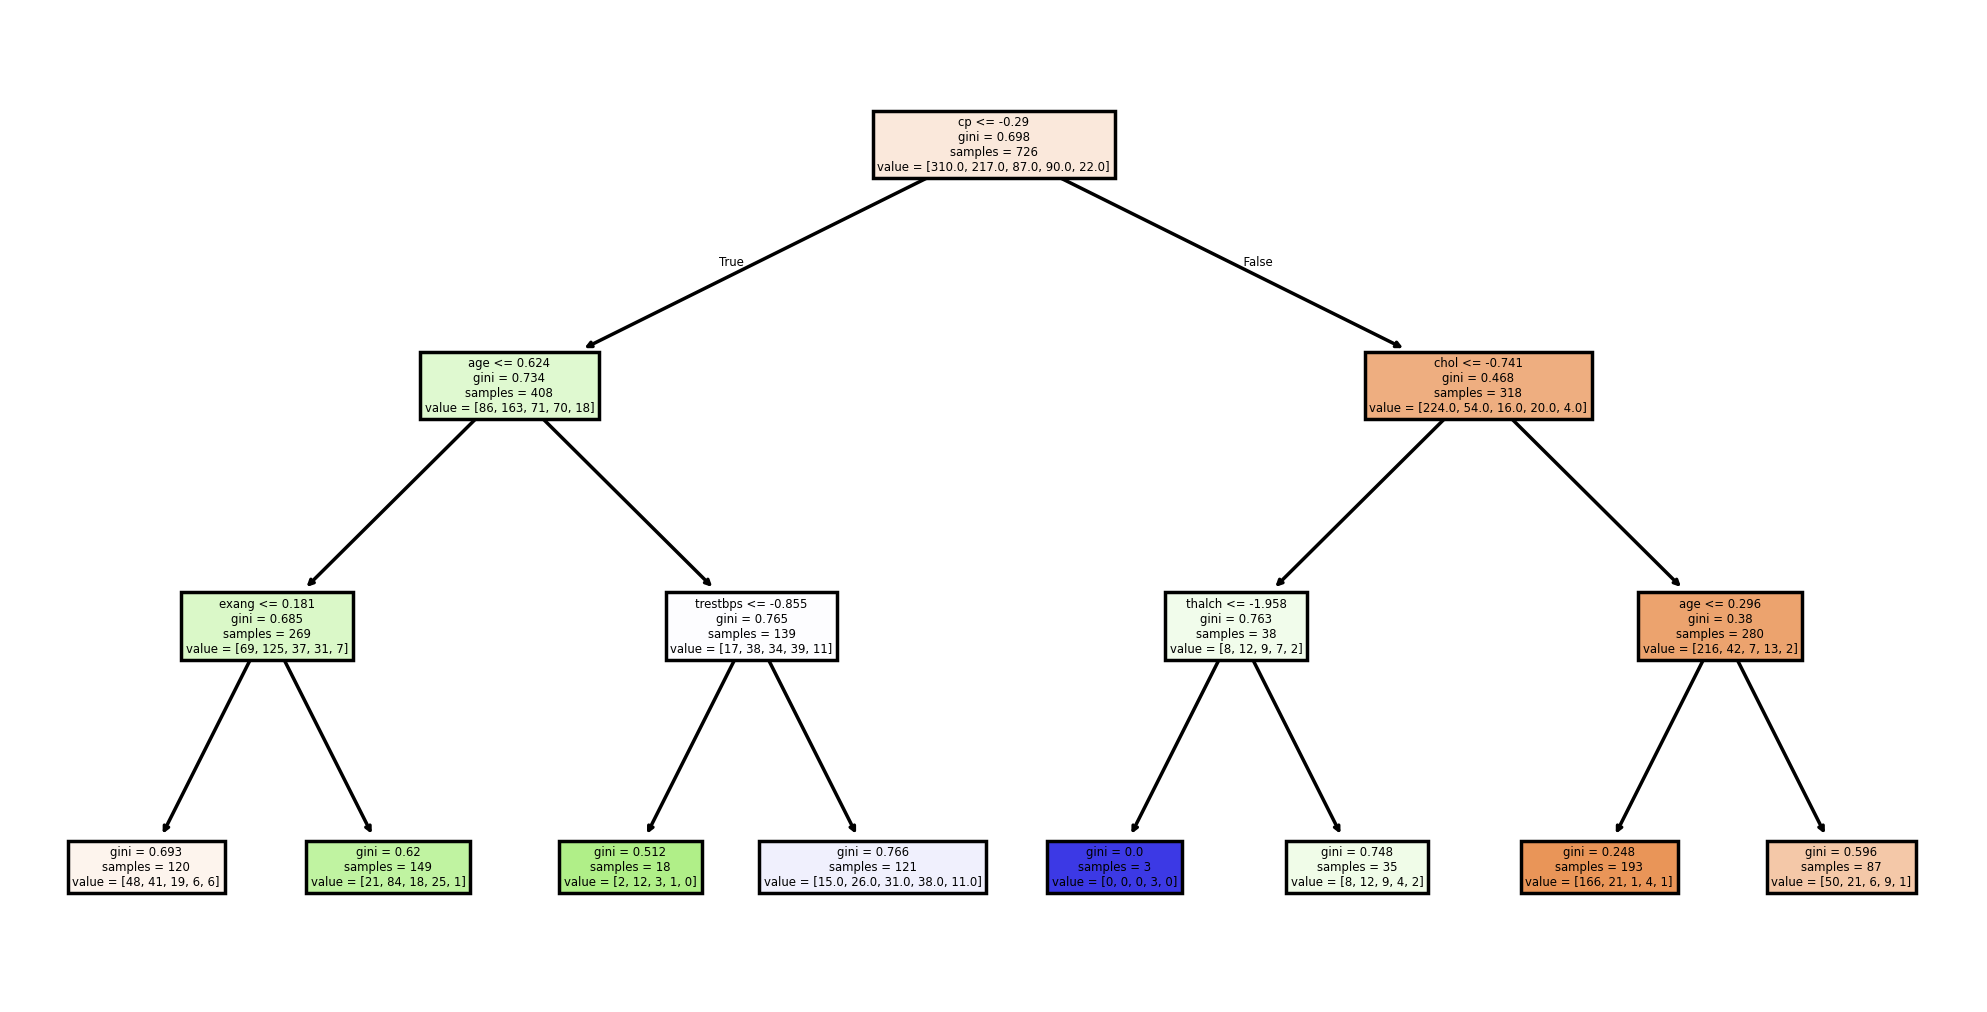

In [60]:
tree.plot_tree(final_model,feature_names=x.columns ,filled=True)
plt.show()

# Interview Questions